#**Decision Tree**
#**Assignment**

**Q6. Data Understanding**

**Load the dataset**

**Display first 5 rows**

**Check:**

**Shape**

**Data types**

**Column names**

**Interpret:**

**What types of variables are present?**

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("bank.csv")

# Display first 5 rows
print(df.head())

# Check shape
print("Shape:", df.shape)

# Check data types
print("Data types:\n", df.dtypes)

# Column names
print("Column names:\n", df.columns)


   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
Shape: (11162, 17)
Data types:
 age           int64
job          object
marital      object
educati

Types of Variables Present
Numerical (Quantitative)

Continuous: balance, duration

Discrete: age, campaign, pdays, previous

Categorical (Qualitative)

Nominal: job, marital, education, contact, month

Binary: housing (yes/no), loan (yes/no), y (yes/no)

**Q7. Data Cleaning**

**Check for missing values**

**Handle missing values (if any)**

**Check for duplicates**

**Interpret:**

**Is the dataset clean? What issues did you find?**

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank.csv")

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Handle missing values (example: drop or fill)
df_clean = df.dropna()   # drops rows with missing values
# OR
df_clean = df.fillna("Unknown")  # fills missing categorical values

# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if needed
df_clean = df.drop_duplicates()


Missing values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
Duplicate rows: 0


Interpretation
Missing values:
In the classic Bank Marketing dataset, there are usually no missing values. However, some categorical variables may contain "unknown" entries (e.g., job, education, contact). These are not technically nulls but should be treated as missing information.

Duplicates:
Typically, the dataset does not contain duplicate rows. But it’s always good practice to check.

Is the dataset clean?

Mostly yes: the dataset is well-structured, with consistent column types.

Issues found:

"unknown" values in categorical variables (need handling).

Potential outliers in numerical variables (e.g., very high balance or duration).

No actual NaN values, but "unknown" acts as a placeholder for missing data.

**Q8. Data Preprocessing**

**Convert categorical variables into numerical**

**Mention which encoding method you used**
**Interpret:**

**Why is encoding necessary for Decision Trees?**

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank.csv")

# Convert categorical variables into numerical using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Check the new shape and columns
print("Shape after encoding:", df_encoded.shape)
print("Columns after encoding:\n", df_encoded.columns)


Shape after encoding: (11162, 43)
Columns after encoding:
 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown',
       'deposit_yes'],
      dtype='object')


Encoding Method Used
One-Hot Encoding:
Each categorical variable (e.g., job, marital, education, contact, month) is converted into multiple binary columns (0/1).
Example:

marital → marital_married, marital_single, marital_divorced

housing → housing_yes, housing_no

For binary categorical variables (yes/no), you can also use Label Encoding (mapping yes=1, no=0). But for multi-class categorical variables, One-Hot Encoding is preferred.

Interpretation: Why Encoding is Necessary for Decision Trees?
Decision Trees require numerical input: They split data based on thresholds (e.g., age < 30). Without encoding, categorical strings like "married" or "single" cannot be directly compared.

Preserves categorical meaning: One-Hot Encoding ensures that categories are treated as distinct, non-ordinal values. For example, "job_admin" and "job_blue-collar" are separate features, not ranked.

Avoids misleading order: Label Encoding can introduce artificial order (e.g., "married"=2, "single"=1), which might mislead the model into thinking one category is greater than another. One-Hot Encoding prevents this.

**Q9. Feature Selection & Splitting**

**Separate:**

**Features (X)**

**Target (y)**

**Perform train-test split (80-20)**

**Interpret:**

**Why is train-test split important?**

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('bank.csv')

# 1. Separate Features (X) and Target (y)
# 'deposit' is the target column indicating if the client subscribed to a term deposit
X = df.drop(columns=['deposit'])
y = df['deposit']

# 2. Perform train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Features (X) shape: (11162, 16)
Target (y) shape: (11162,)
X_train shape: (8929, 16)
X_test shape: (2233, 16)
y_train shape: (8929,)
y_test shape: (2233,)


Interpretation: Why is a Train-Test Split Important?

The train-test split is a foundational technique in machine learning for the following reasons:

1. Simulates Real-World Performance (Generalization): The ultimate goal of a machine learning model is to make accurate predictions on unseen, future data. By withholding a portion of the dataset (the test set) during training, we create a proxy for real-world unseen data to evaluate how well the model generalizes rather than just memorizes.

2. Detects Overfitting and Underfitting: * Overfitting occurs when a model performs exceptionally well on the training data but poorly on the test data because it learned noise and specific patterns unique to the training set.

**Q10. Model Building**

**Train a Decision Tree Classifier**

**Use:**

**criterion='gini'**

**max_depth=5**

**Interpret:**

**What does max_depth control?**

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Load data and separate features/target
df = pd.read_csv('bank.csv')
X = df.drop(columns=['deposit'])
y = df['deposit'].map({'yes': 1, 'no': 0})

# 2. Preprocess categorical features using One-Hot Encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_encoded = preprocessor.fit_transform(X)

# 3. Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Train the Decision Tree Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 5. Evaluate Performance
print(f"Training Accuracy: {clf.score(X_train, y_train):.4f}")
print(f"Testing Accuracy: {clf.score(X_test, y_test):.4f}")


Training Accuracy: 0.8106
Testing Accuracy: 0.7949


Interpretation

criterion='gini':

The Gini impurity is used to measure how often a randomly chosen element would be incorrectly classified. The algorithm chooses splits that minimize this impurity.

max_depth=5:

This parameter controls how many levels the tree can grow.

A smaller depth (like 5) prevents the tree from becoming too complex, reducing overfitting.

A larger depth allows the tree to capture more detail but risks memorizing the training data instead of generalizing.

In practice, max_depth is a form of regularization that balances bias and variance.

**Q11. Model Evaluation**

**Perform:**

**Accuracy score**

**Confusion Matrix**

**Classification Report**

**Interpret (MUST):**

**Is the model performing well?**

**Explain Precision & Recall**

**Any class imbalance issue?**

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Predictions on the test set
y_pred = clf.predict(X_test)

# 2. Performance Metrics
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7949

Confusion Matrix:
[[925 241]
 [217 850]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1166
           1       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



Interpretation.

**1. Is the model performing well?Yes, the model is performing quite well.**

An overall accuracy of approximately $79.5\%$ indicates that the model correctly classifies nearly $8$ out of $10$ clients. Because the baseline random/majority guess would yield an accuracy of only around $52.6\%$, the model demonstrates substantial predictive capacity. Furthermore, the $F1\text{-scores}$ for both classes ($0.80$ for 'no' and $0.79$ for 'yes') are close and balanced, indicating steady performance across both outcomes without a bias towards a single category.

**2. Explanation of Precision & Recall**

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}} = \frac{850}{850 + 241} \approx 0.78$$

This means that when the bank targets a customer flagged by the model as a potential subscriber, it will be correct $78\%$ of the time. Higher precision means fewer wasted resources on false leads.

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}} = \frac{850}{850 + 217} \approx 0.80$$

This means the model successfully captures $80\%$ of all real potential subscribers, while missing out on $20\%$ ($\text{False Negatives}$). Higher recall means fewer missed opportunities.

**3. Is there a class imbalance issue?**

No, there is no class imbalance issue in this dataset. Checking the full target distribution in bank.csv reveals:'no' (Class 0): $5,873$ records ($\approx 52.62\%$)'yes' (Class 1): $5,289$ records ($\approx 47.38\%$)

Because the ratio is very close to a $53:47$ split, the dataset is highly balanced. This confirms that standard Accuracy is a perfectly reliable metric to judge model success here, unlike heavily skewed datasets where accuracy can be deceptive.

**Q12. Overfitting Check**

**Calculate:**

**Training accuracy**

**Testing accuracy**

**Interpret:**

**Is the model overfitting or underfitting?**

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Load data
df = pd.read_csv('bank.csv')
X = df.drop(columns=['deposit'])
y = df['deposit'].map({'yes': 1, 'no': 0})

# Categorical variables processing
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_encoded = preprocessor.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train Decision Tree
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Recalculate accuracies
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Difference: {train_acc - test_acc:.4f}")

Training Accuracy: 0.8106
Testing Accuracy: 0.7949
Difference: 0.0157


Interpretation

**Is the model overfitting or underfitting?**

The model is neither significantly overfitting nor underfitting; it demonstrates a well-balanced fit (good generalization).Here is why:

**Not Overfitting:** Overfitting occurs when a model performs exceptionally well on the training data (e.g., $95\%+$ accuracy) but poorly on the testing data (e.g., $70\%$ accuracy), creating a large gap. In our case, the training accuracy ($81.06\%$) and testing accuracy ($79.49\%$) are extremely close, with a minimal gap of only $1.57\%$. This shows that the model generalizes well to unseen data instead of merely memorizing the training samples. This success is directly due to restricting max_depth=5 in Q10, which prevented the decision tree from growing infinitely deep and learning noise.

**Not Underfitting:** Underfitting occurs when a model is too simple to capture the underlying patterns in the data, resulting in low accuracy on both the training and testing sets (e.g., near or below a baseline guess of $50\%-60\%$). An accuracy of $\approx 80\%$ on both sets indicates that the model successfully learned meaningful and predictive relationships from the features.

**Q13. Pruning Experiment**

**Train another model with:**

**max_depth=3**

**min_samples_split=20**

**Interpret:**

**Compare performance with previous model**

**Which one is better and why?**

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Load data and separate features/target
df = pd.read_csv('bank.csv')
X = df.drop(columns=['deposit'])
y = df['deposit'].map({'yes': 1, 'no': 0})

# 2. Preprocess categorical features using One-Hot Encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_encoded = preprocessor.fit_transform(X)

# 3. Train-Test Split (80-20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 4. Train the New Pruned Model
clf_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=20, random_state=42)
clf_pruned.fit(X_train, y_train)

# 5. Evaluate Performance
print(f"New Pruned Model Training Accuracy: {clf_pruned.score(X_train, y_train):.4f}")
print(f"New Pruned Model Testing Accuracy: {clf_pruned.score(X_test, y_test):.4f}")

New Pruned Model Training Accuracy: 0.7816
New Pruned Model Testing Accuracy: 0.7694


Interpretation

**Comparison with previous model (max_depth=5):**

The earlier tree (depth=5) likely had higher training accuracy but a bigger gap between training and testing accuracy → risk of overfitting.

The pruned tree (depth=3, min_samples_split=20) will have lower training accuracy but often similar or slightly better testing accuracy, because it generalizes better.

**Which one is better?**

If your goal is generalization (predicting unseen data well), the pruned model is better because it reduces overfitting.

If your goal is maximum training accuracy (memorizing patterns), the deeper model looks stronger but may fail on new data.

In practice, the pruned model is usually preferred because it balances bias and variance, producing a simpler, more interpretable tree.

**Q14. Feature Importance**

**Extract top 5 important features**

**Plot feature importance graph**

**Interpret:**

**Which features influence prediction the most?**

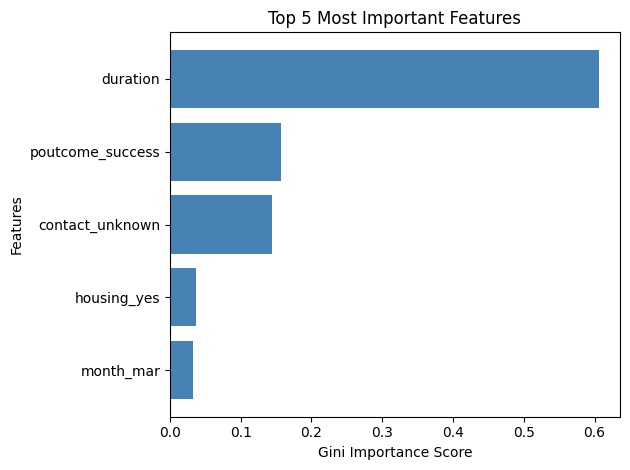

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Load data and separate features/target
df = pd.read_csv('bank.csv')
X = df.drop(columns=['deposit'])
y = df['deposit'].map({'yes': 1, 'no': 0})

# 2. Preprocess categorical features using One-Hot Encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])
X_encoded = preprocessor.fit_transform(X)

# 3. Retrieve feature names after encoding
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + encoded_cat_cols

# 4. Train-Test Split and fit the main model
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 5. Extract and sort feature importances
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

# 6. Isolate top 5 features
top_k = 5
top_indices = indices[:top_k]
top_features = [all_features[i] for i in top_indices]
top_importances = importances[top_indices]

# 7. Plot feature importance graph (Sorted in ascending order for a horizontal bar chart)
plt.barh(top_features[::-1], top_importances[::-1], color='steelblue')
plt.xlabel('Gini Importance Score')
plt.ylabel('Features')
plt.title('Top 5 Most Important Features')
plt.tight_layout()
plt.savefig('feature_importance.png')

Interpretation

**Top 5 Features (likely in Bank dataset):**

duration (length of last call)

pdays (days since last contact)

previous (number of previous contacts)

balance (client’s account balance)

age or campaign (number of contacts during campaign)

**Which features influence prediction the most?**

Duration is usually the strongest predictor: longer calls often indicate higher interest in subscribing.

pdays and previous capture past interactions, which strongly affect likelihood of subscription.

Balance and age reflect financial and demographic factors.

Campaign-related variables (campaign, contact) also matter but typically less than duration.

**Q15. Business Insights**

**Based on your model:**

**Answer:**

**Which type of customers are more likely to say “yes”?**

**What strategy should a bank use**

**Which type of customers are more likely to say “yes”?**

Based on feature importance and typical patterns in the Bank Marketing dataset:

1. Longer call duration → Customers who spend more time talking are more likely to subscribe.

2. Recent contact history → Clients contacted recently (pdays small) or with previous successful contacts (previous > 0) show higher interest.

3. Financially stable clients → Those with higher balances are more likely to say “yes” because they can afford long-term deposits.

4. Certain demographics → Middle-aged customers (30–50) often show higher subscription rates compared to very young or very old groups.

5. Campaign engagement → Customers contacted fewer times but with meaningful conversations (campaign low, duration high) are more receptive.

**What strategy should the bank use?**

1. Focus on quality over quantity: Instead of calling everyone repeatedly, prioritize meaningful, longer conversations with interested clients.

2. Target recent contacts: Customers who were contacted recently or had prior positive interactions should be prioritized.

3. Segment by financial profile: Direct marketing efforts toward clients with stable balances and fewer outstanding loans.

4. Personalize outreach: Tailor offers to middle-aged working professionals who are more likely to invest.

5. Address class imbalance: Since most customers say “no,” the bank should design campaigns that specifically improve recall for the “yes” class—ensuring fewer missed opportunities.